In [1]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional
import matplotlib.pyplot as plt

def create_sequence(dataset):
  sequences = []
  labels = []

  start_idx = 0

  for stop_idx in range(50,len(dataset)): 
    sequences.append(dataset.iloc[start_idx:stop_idx])
    labels.append(dataset.iloc[stop_idx])
    start_idx += 1
  
  return (np.array(sequences),np.array(labels))


sqlite_database = 'database/base.db'
sqlite_conn = sqlite3.connect(sqlite_database)
sqlite_select_query = f"""SELECT * FROM instrument_history_minute WHERE date > '2022-01-03' and date < '2022-02-01' """
sqlquery_pd = pd.read_sql_query(sqlite_select_query,sqlite_conn)
gstock_data = pd.DataFrame(sqlquery_pd, columns = ['date', 'close'])
gstock_data['date'] = gstock_data['date'].apply(lambda x: datetime.strptime(x,'%Y-%m-%d %H:%M:%S'))
#gstock_data ['date'] = pd.<a onclick="parent.postMessage({'referent':'.pandas.to_datetime'}, '*')">to_datetime(gstock_data ['date'].apply(lambda x: x.split()[0])) 
gstock_data .set_index('date',drop=True,inplace=True) 
# gstock_data .head()
gstock_data .info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7500 entries, 2022-01-03 09:15:00 to 2022-01-31 15:29:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   7500 non-null   float64
dtypes: float64(1)
memory usage: 117.2 KB


In [2]:
Ms = MinMaxScaler()
gstock_data [gstock_data .columns] = Ms.fit_transform(gstock_data )
training_size = round(len(gstock_data ) * 0.90)
train_data = gstock_data [:training_size]
test_data  = gstock_data [training_size:]

In [3]:
train_seq, train_label = create_sequence(train_data)
test_seq, test_label = create_sequence(test_data)

In [4]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape = (train_seq.shape[1], train_seq.shape[2])))

model.add(Dropout(0.1)) 
model.add(LSTM(units=50))

model.add(Dense(2))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 50, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 2)                 102       
                                                                 
Total params: 30,702
Trainable params: 30,702
Non-trainable params: 0
_________________________________________________________________


In [5]:
model.fit(train_seq, train_label, epochs=50,validation_data=(test_seq, test_label), verbose=1)
test_predicted = model.predict(test_seq)

Epoch 1/50
210/210 [==============================] - 10s 29ms/step - loss: 0.0141 - mean_absolute_error: 0.0548 - val_loss: 4.6602e-04 - val_mean_absolute_error: 0.0148
Epoch 2/50
210/210 [==============================] - 6s 27ms/step - loss: 6.1254e-04 - mean_absolute_error: 0.0183 - val_loss: 4.5336e-04 - val_mean_absolute_error: 0.0147
Epoch 3/50
210/210 [==============================] - 6s 27ms/step - loss: 5.7541e-04 - mean_absolute_error: 0.0177 - val_loss: 4.2921e-04 - val_mean_absolute_error: 0.0142
Epoch 4/50
210/210 [==============================] - 5s 24ms/step - loss: 5.4460e-04 - mean_absolute_error: 0.0171 - val_loss: 4.2748e-04 - val_mean_absolute_error: 0.0141
Epoch 5/50
210/210 [==============================] - 5s 24ms/step - loss: 5.2775e-04 - mean_absolute_error: 0.0170 - val_loss: 4.3964e-04 - val_mean_absolute_error: 0.0146
Epoch 6/50
210/210 [==============================] - 5s 24ms/step - loss: 4.7938e-04 - mean_absolute_error: 0.0159 - val_loss: 3.6884e-04

210/210 [==============================] - 6s 26ms/step - loss: 9.9761e-05 - mean_absolute_error: 0.0071 - val_loss: 8.9660e-05 - val_mean_absolute_error: 0.0059
Epoch 49/50
210/210 [==============================] - 6s 29ms/step - loss: 1.0772e-04 - mean_absolute_error: 0.0074 - val_loss: 8.9806e-05 - val_mean_absolute_error: 0.0059
Epoch 50/50
22/22 [==============================] - 1s 13ms/step


In [9]:
test_inverse_predicted = Ms.inverse_transform(test_predicted)
test_inverse_predicted

array([[38264.824, 38262.04 ],
       [38226.566, 38226.73 ],
       [38215.465, 38214.902],
       ...,
       [37952.023, 37950.89 ],
       [37958.133, 37956.473],
       [37951.047, 37950.184]], dtype=float32)

In [10]:
gsstock_actual = gstock_data.tail(375).copy()
gsstock_predict_all = pd.DataFrame(test_inverse_predicted,columns=['open_predicted','close_predicted'], index=gstock_data .iloc[-700:].index)
gsstock_predict = gsstock_predict_all.tail(375).copy()

In [14]:
gs_slic_data = pd.concat((gsstock_actual,gsstock_predict), axis=1)
gs_slic_data[['close']] = Ms.inverse_transform(gs_slic_data[['close']])
gs_slic_data.to_csv()

'date,close,open_predicted,close_predicted\r\n2022-01-31 09:15:00,38112.65,37682.09,37682.016\r\n2022-01-31 09:16:00,38186.45,38044.777,38024.277\r\n2022-01-31 09:17:00,38131.65,38191.43,38180.164\r\n2022-01-31 09:18:00,38145.5,38134.395,38141.59\r\n2022-01-31 09:19:00,38158.85,38121.918,38132.664\r\n2022-01-31 09:20:00,38147.95,38139.266,38146.76\r\n2022-01-31 09:21:00,38131.55,38135.12,38140.387\r\n2022-01-31 09:22:00,38117.2,38120.086,38123.46\r\n2022-01-31 09:23:00,38052.55,38107.836,38108.984\r\n2022-01-31 09:24:00,38010.8,38051.5,38053.52\r\n2022-01-31 09:25:00,37953.6,38007.926,38008.477\r\n2022-01-31 09:26:00,37999.15,37956.05,37955.76\r\n2022-01-31 09:27:00,38053.55,37991.633,37985.367\r\n2022-01-31 09:28:00,37994.15,38051.13,38042.227\r\n2022-01-31 09:29:00,37991.3,38004.867,38003.13\r\n2022-01-31 09:30:00,37961.95,37987.266,37987.12\r\n2022-01-31 09:31:00,38032.15,37961.656,37962.426\r\n2022-01-31 09:32:00,38034.8,38019.52,38015.418\r\n2022-01-31 09:33:00,38032.25,38033.996,

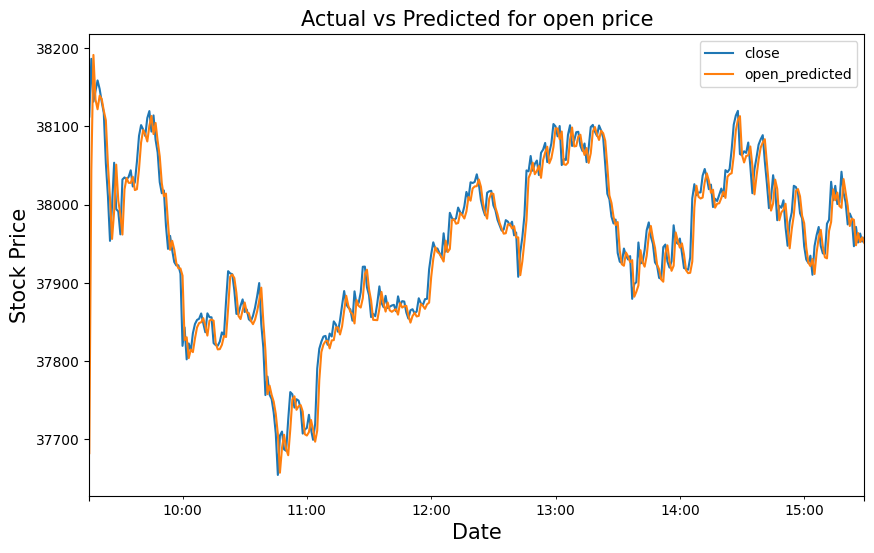

In [12]:
gs_slic_data[['close','open_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for open price',size=15)
plt.show()

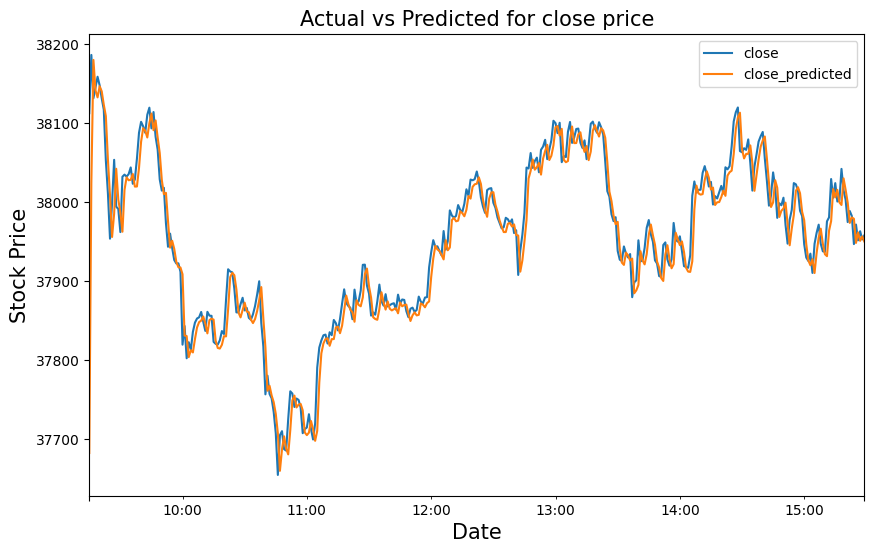

In [13]:
gs_slic_data[['close','close_predicted']].plot(figsize=(10,6))
plt.xticks(rotation=45)
plt.xlabel('Date',size=15)
plt.ylabel('Stock Price',size=15)
plt.title('Actual vs Predicted for close price',size=15)
plt.show()